<a href="https://colab.research.google.com/github/filipecalegario/intro-programacao-python/blob/main/11_Dados_Visualizacao/Exercicio_series_historicas_preenchido_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/filipecalegario/intro-programacao-python/blob/main/11_Dados_Visualizacao/Exercicio_series_historicas.ipynb)

# 📊 Aula de Pandas — Junção de Séries Históricas

Nesta aula vamos aprender a:

1. **Importar** múltiplos CSVs com formatação brasileira (vírgula decimal, ponto como separador de milhar)
2. **Tratar** e padronizar cada DataFrame
3. **Juntar** as três séries em um único DataFrame usando datas como chave
4. **Visualizar** as séries em um gráfico de linhas
5. **Calcular** a correlação entre os ativos

### Dados utilizados
| Arquivo | Ativo | Fonte
|---|---|---
| `ouro.csv` | Ouro (futuros, USD) | https://br.investing.com/commodities/gold-historical-data
| `petroleo.csv` | Petróleo Brent (futuros, USD) | https://br.investing.com/commodities/brent-oil-historical-data
| `petr4.csv` | PETR4 (Petrobras PN, BRL) | https://br.investing.com/equities/petrobras-pn-historical-data

> Fonte: Investing.com

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Configurações visuais
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## 2. Leitura dos CSVs

Os arquivos do Investing.com vêm com formatação brasileira:
- Datas no formato `dd.mm.aaaa`
- Números com **ponto** como separador de milhar e **vírgula** como decimal (ex: `5.202,51`)
- Colunas entre aspas

Vamos criar uma **função auxiliar** para ler e tratar cada arquivo de forma padronizada.

In [2]:
def ler_investing_csv(caminho: str, nome_coluna: str) -> pd.DataFrame:
    """
    Lê um CSV do Investing.com (formato BR) e retorna um DataFrame
    com DatetimeIndex e uma única coluna de preço de fechamento.

    Parâmetros
    ----------
    caminho : str
        Caminho para o arquivo CSV.
    nome_coluna : str
        Nome que a coluna de preço receberá no DataFrame final.
    """
    df = pd.read_csv(caminho, encoding='utf-8')  # sem decimal=','

    df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')

    df[nome_coluna] = (
        df['Último']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    df = df[['Data', nome_coluna]].set_index('Data').sort_index()
    return df

print("Função 'ler_investing_csv' criada com sucesso! ✅")

Função 'ler_investing_csv' criada com sucesso! ✅


### 2.1 Aplicando a função nos três arquivos

In [7]:
df_ouro = ler_investing_csv('https://raw.githubusercontent.com/filipecalegario/intro-programacao-python/refs/heads/main/11_Dados_Visualizacao/ouro.csv', 'Ouro_USD')
df_brent = ler_investing_csv('https://raw.githubusercontent.com/filipecalegario/intro-programacao-python/refs/heads/main/11_Dados_Visualizacao/petroleo.csv', 'Brent_USD')
df_petr4 = ler_investing_csv('https://raw.githubusercontent.com/filipecalegario/intro-programacao-python/refs/heads/main/11_Dados_Visualizacao/petr4.csv', 'PETR4_BRL')

print(f"Ouro:  {df_ouro.shape} registros | de {df_ouro.index.min().date()} até {df_ouro.index.max().date()}")
print(f"Brent: {df_brent.shape} registros  |  de {df_brent.index.min().date()} até {df_brent.index.max().date()}")
print(f"PETR4: {df_petr4.shape} registros  |  de {df_petr4.index.min().date()} até {df_petr4.index.max().date()}")

Ouro:  (51, 1) registros | de 2026-01-01 até 2026-03-10
Brent: (48, 1) registros  |  de 2026-01-02 até 2026-03-10
PETR4: (145, 1) registros  |  de 2025-08-11 até 2026-03-10


### 2.2 Espiando cada DataFrame

In [ ]:
df_ouro

In [9]:
df_brent.tail()

,Brent_USD
Data,
2026-03-04,81.40
2026-03-05,85.41
2026-03-06,92.69
2026-03-09,98.96
2026-03-10,90.69


In [10]:
df_petr4.head()

,PETR4_BRL
Data,
2025-08-11,30.72
2025-08-12,30.80
2025-08-13,30.57
2025-08-14,30.18
2025-08-15,29.50


## 3. Junção das séries em um único DataFrame

Como os três DataFrames já estão indexados por data, podemos usar o método `pd.concat` ou `.join()`.

⚠️ **Ponto de atenção:** os DataFrames podem ter datas diferentes (feriados, dias úteis distintos entre bolsas). Precisamos decidir como tratar isso:

| Estratégia | Método | O que acontece |
|---|---|---|
| **inner join** | mantém apenas datas em comum | perde dados, mas sem valores nulos |
| **outer join** | mantém todas as datas | pode gerar NaN onde não há dado |

Vamos usar **inner join** para garantir que todas as linhas tenham valores válidos.

In [15]:
# Junção com inner join (apenas datas em que TODOS os ativos têm cotação)
df = df_ouro.join(df_brent, how='inner')
df = df.join(df_petr4, how='inner')

print(f"DataFrame combinado: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Período: {df.index.min().date()} a {df.index.max().date()}\n")
df.head(10)

DataFrame combinado: 46 linhas × 3 colunas
Período: 2026-01-02 a 2026-03-10



,Ouro_USD,Brent_USD,PETR4_BRL
Data,,,
2026-01-02,4329.6,60.75,30.71
2026-01-05,4451.5,61.76,30.20
2026-01-06,4496.1,60.70,29.64
2026-01-07,4462.5,59.96,29.83
2026-01-08,4460.7,61.99,30.20
2026-01-09,4500.9,63.34,30.30
2026-01-12,4614.7,63.87,30.36
2026-01-13,4599.1,65.47,31.14
2026-01-14,4635.7,66.52,31.99


In [ ]:
df_exemplo = df_ouro.join(df_brent, how='right')
df_exemplo

### 3.1 Comparando: o que aconteceria com outer join?

In [16]:
df_outer = df_ouro.join(df_brent, how='outer').join(df_petr4, how='outer')

print(f"Com outer join: {df_outer.shape[0]} linhas")
print(f"Valores nulos por coluna:")
print(df_outer.isnull().sum())

Com outer join: 150 linhas
Valores nulos por coluna:
Ouro_USD      99
Brent_USD    102
PETR4_BRL      5
dtype: int64


In [ ]:
df_outer

In [22]:
df_concat = pd.concat([df_ouro, df_brent, df_petr4], axis=1).dropna()
df_concat

,Ouro_USD,Brent_USD,PETR4_BRL
Data,,,
2026-01-02,4329.60,60.75,30.71
2026-01-05,4451.50,61.76,30.20
2026-01-06,4496.10,60.70,29.64
2026-01-07,4462.50,59.96,29.83
2026-01-08,4460.70,61.99,30.20
2026-01-09,4500.90,63.34,30.30
2026-01-12,4614.70,63.87,30.36
2026-01-13,4599.10,65.47,31.14
2026-01-14,4635.70,66.52,31.99


In [ ]:
df

## 4. Exploração rápida do DataFrame combinado

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 46 entries, 2026-01-02 to 2026-03-10
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ouro_USD   46 non-null     float64
 1   Brent_USD  46 non-null     float64
 2   PETR4_BRL  46 non-null     float64
dtypes: float64(3)
memory usage: 1.4 KB


In [25]:
df.describe()

,Ouro_USD,Brent_USD,PETR4_BRL
count,46.000000,46.000000,46.000000
mean,4924.655652,69.863696,36.139783
std,274.590559,8.428204,3.849768
min,4329.600000,59.960000,29.640000
25%,4657.237500,64.275000,32.200000
50%,5003.450000,67.900000,37.215000
75%,5118.700000,70.830000,38.462500
max,5354.800000,98.960000,43.160000


## 5. Visualização — Gráfico de linhas

Como as escalas são muito diferentes (Ouro ~5000, Brent ~70-90, PETR4 ~35-43), vamos usar **normalização Min-Max** ou **eixos múltiplos** para que as três séries sejam comparáveis visualmente.

### 5.1 Gráfico com valores normalizados (base 100)

A normalização "base 100" é uma técnica comum no mercado financeiro: cada série começa em 100 e mostra a variação percentual acumulada.

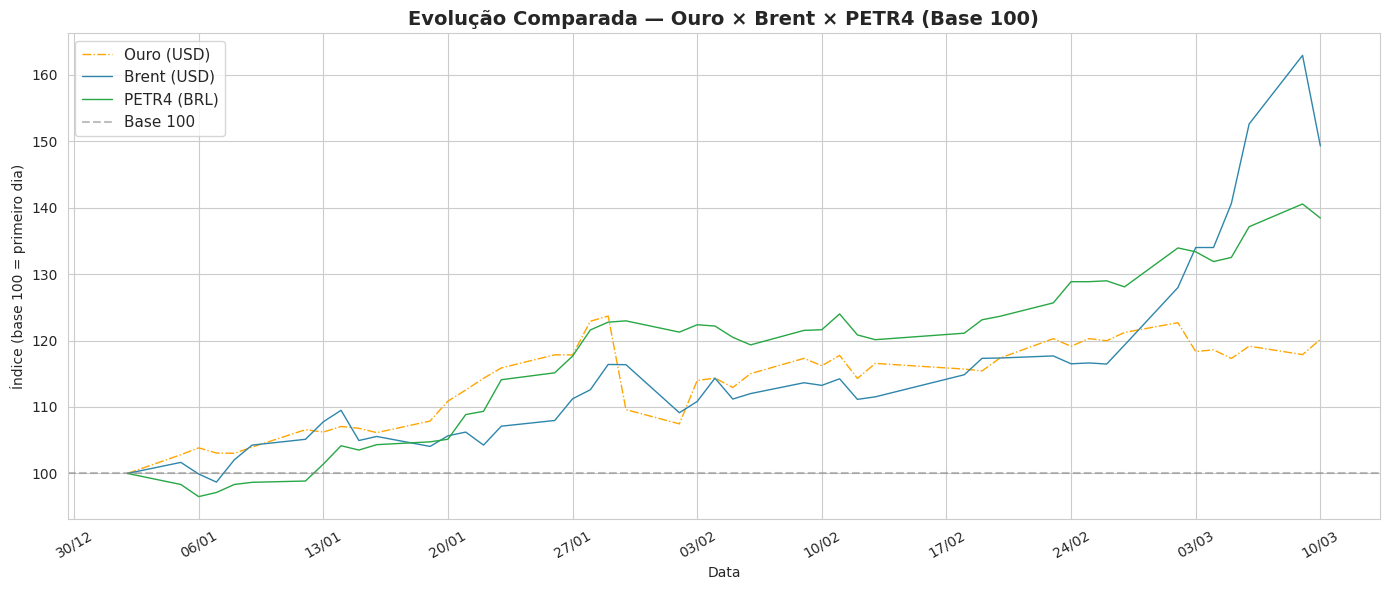

In [43]:
# Normalização base 100: cada série dividida pelo seu primeiro valor × 100
df_norm = df / df.iloc[0] * 100

x = range(len(df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_norm.index, df_norm['Ouro_USD'],  label='Ouro (USD)',  linewidth=1, color='orange', linestyle='-.')
ax.plot(df_norm.index, df_norm['Brent_USD'], label='Brent (USD)', linewidth=1, color='#2E86AB')
ax.plot(df_norm.index, df_norm['PETR4_BRL'], label='PETR4 (BRL)', linewidth=1, color='#28A745')

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Base 100')

ax.set_title('Evolução Comparada — Ouro × Brent × PETR4 (Base 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Índice (base 100 = primeiro dia)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 5.2 Gráfico com eixos Y múltiplos (valores absolutos)

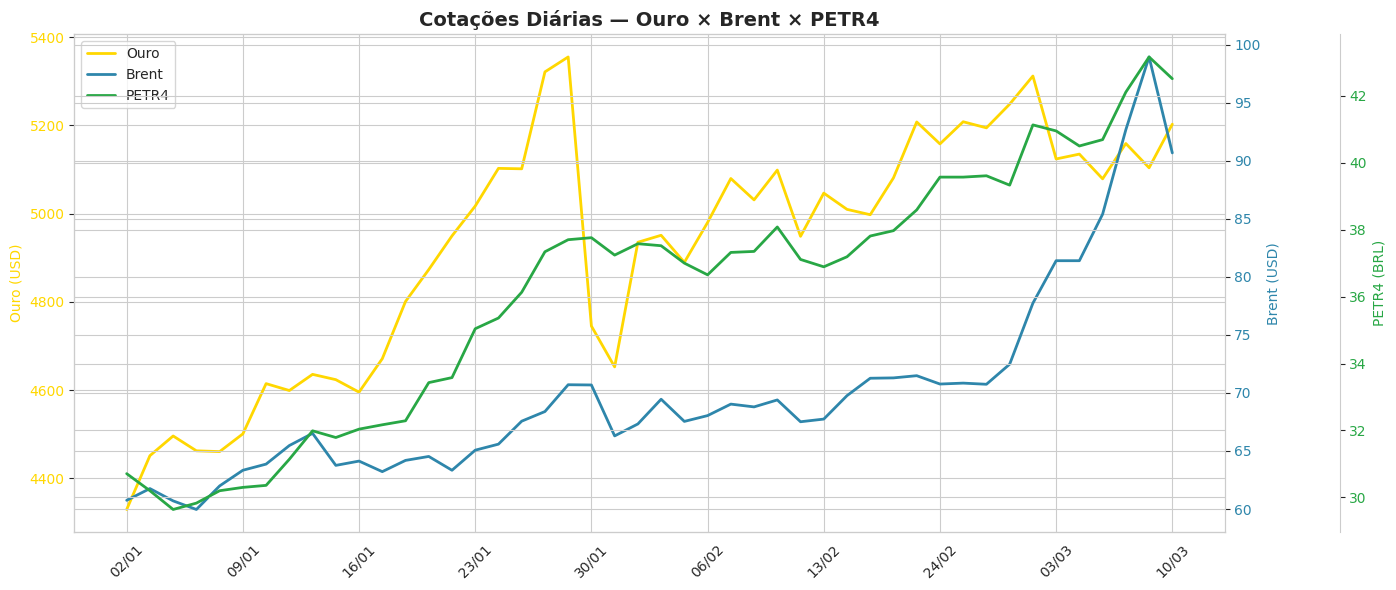

In [46]:
fig, ax1 = plt.subplots()
c1, c2, c3 = '#FFD700', '#2E86AB', '#28A745'

x = range(len(df))  # posição inteira em vez de datas

ax1.plot(x, df['Ouro_USD'].values, color=c1, lw=2, label='Ouro')
ax1.set_ylabel('Ouro (USD)', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)

ax2 = ax1.twinx()
ax2.plot(x, df['Brent_USD'].values, color=c2, lw=2, label='Brent')
ax2.set_ylabel('Brent (USD)', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.1))
ax3.plot(x, df['PETR4_BRL'].values, color=c3, lw=2, label='PETR4')
ax3.set_ylabel('PETR4 (BRL)', color=c3)
ax3.tick_params(axis='y', labelcolor=c3)

# Labels de data espaçados (a cada 5 pregões)
tick_pos = list(range(0, len(df), 5))
tick_labels = [df.index[i].strftime('%d/%m') for i in tick_pos]
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_labels, rotation=45)

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0] + ax3.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1] + ax3.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='upper left')
ax1.set_title('Cotações Diárias — Ouro × Brent × PETR4', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Análise de Correlação

### 6.1 Correlação de Pearson (nos preços)

A correlação de Pearson mede a relação linear entre duas variáveis:
- **+1**: correlação positiva perfeita
- **0**: sem correlação linear
- **-1**: correlação negativa perfeita

⚠️ **Cuidado:** correlação entre *preços* pode ser enganosa (duas séries que apenas sobem ao longo do tempo terão alta correlação sem necessariamente ter relação causal). Por isso, também vamos calcular a correlação dos **retornos diários**.

In [48]:
# Matriz de correlação dos PREÇOS
corr_precos = df.corr()

# print("Matriz de Correlação (Preços):")
# print(corr_precos.round(4))
corr_precos

,Ouro_USD,Brent_USD,PETR4_BRL
Ouro_USD,1.000000,0.593616,0.857559
Brent_USD,0.593616,1.000000,0.829902
PETR4_BRL,0.857559,0.829902,1.000000


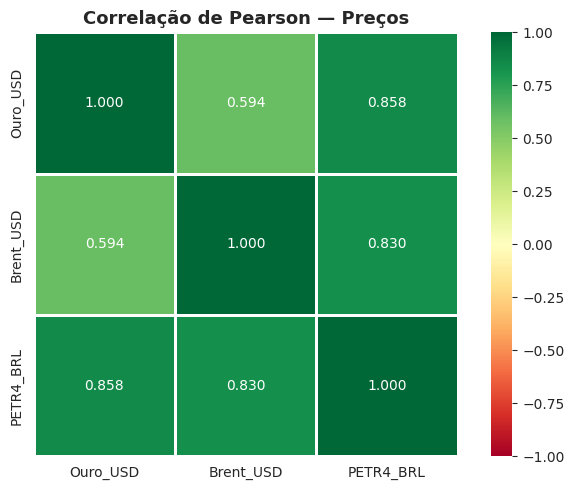

In [49]:
# Heatmap da correlação dos preços
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_precos,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    ax=ax
)
ax.set_title('Correlação de Pearson — Preços', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Correlação dos retornos diários (mais robusta)

Os retornos diários eliminam a tendência de alta/baixa e capturam melhor a relação real entre os ativos.

In [50]:
# Calcula retornos percentuais diários
retornos = df.pct_change().dropna()

print("Primeiros retornos diários:")
retornos.head()

Primeiros retornos diários:


,Ouro_USD,Brent_USD,PETR4_BRL
Data,,,
2026-01-05,0.028155,0.016626,-0.016607
2026-01-06,0.010019,-0.017163,-0.018543
2026-01-07,-0.007473,-0.012191,0.006410
2026-01-08,-0.000403,0.033856,0.012404
2026-01-09,0.009012,0.021778,0.003311


In [52]:
retornos.plot()

SyntaxError: incomplete input (921443920.py, line 1)

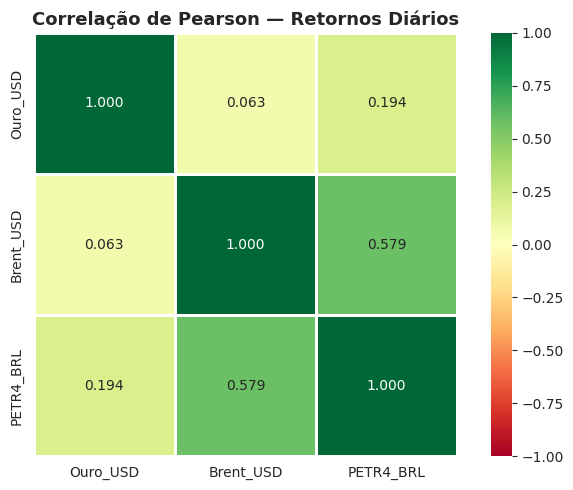

In [53]:
# Matriz de correlação dos RETORNOS
corr_retornos = retornos.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_retornos,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    ax=ax
)
ax.set_title('Correlação de Pearson — Retornos Diários', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Teste estatístico de significância (Pearson com p-valor)

Agora vamos além da simples matriz: usamos `scipy.stats.pearsonr` para obter o **p-valor** de cada par. Um p-valor < 0.05 indica que a correlação é estatisticamente significativa.

In [54]:
# Teste de correlação de Pearson com p-valor para cada par de ativos
pares = [
    ('Ouro_USD', 'Brent_USD'),
    ('Ouro_USD', 'PETR4_BRL'),
    ('Brent_USD', 'PETR4_BRL'),
]

print("=" * 65)
print(f"{'Par':<25} {'Pearson r':>10} {'p-valor':>12} {'Significativo?':>16}")
print("=" * 65)

for col_a, col_b in pares:
    r, p = stats.pearsonr(retornos[col_a], retornos[col_b])
    sig = '✅ Sim' if p < 0.05 else '❌ Não'
    print(f"{col_a} × {col_b:<10} {r:>10.4f} {p:>12.6f} {sig:>16}")

print("=" * 65)
print("\n(Calculado sobre os retornos diários)")

Par                        Pearson r      p-valor   Significativo?
Ouro_USD × Brent_USD      0.0633     0.679722            ❌ Não
Ouro_USD × PETR4_BRL      0.1936     0.202520            ❌ Não
Brent_USD × PETR4_BRL      0.5787     0.000031            ✅ Sim

(Calculado sobre os retornos diários)


### 6.4 Scatter plots dos retornos — visualizando a correlação

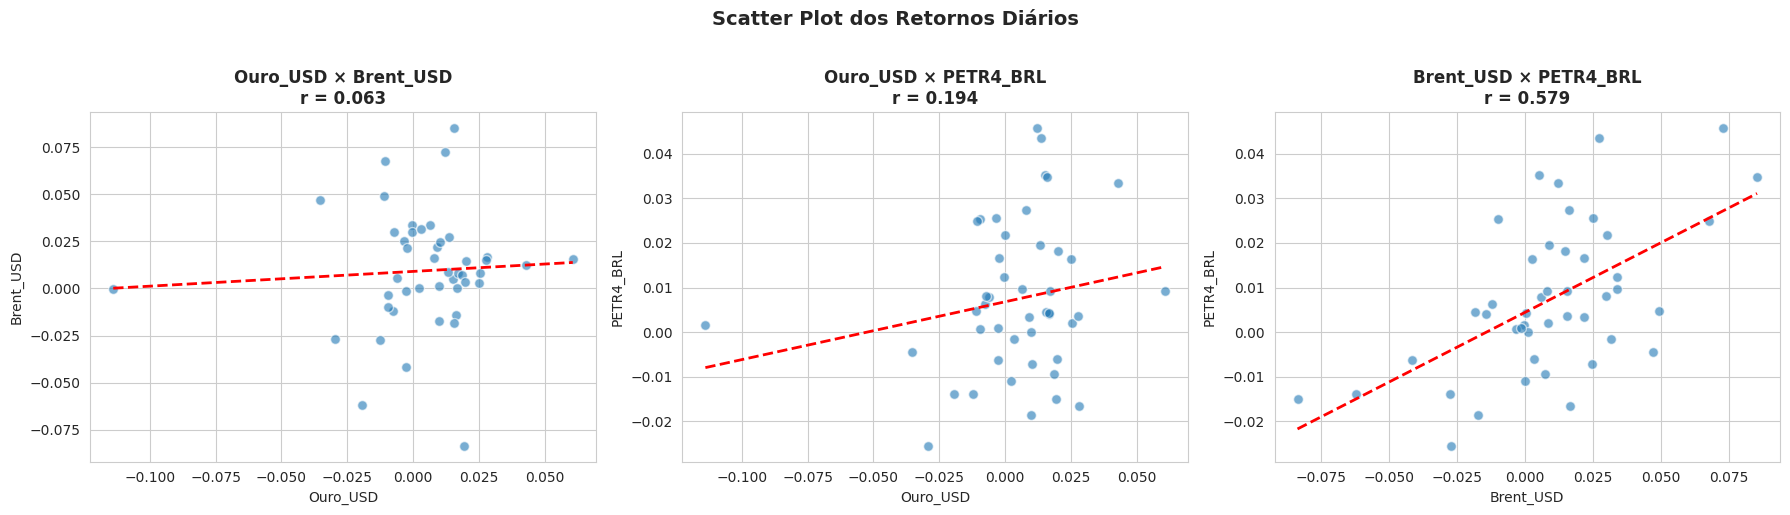

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col_a, col_b) in zip(axes, pares):
    ax.scatter(retornos[col_a], retornos[col_b], alpha=0.6, edgecolors='w', s=50)

    # Linha de regressão
    m, b = np.polyfit(retornos[col_a], retornos[col_b], 1) if True else (0, 0)
    x_line = np.linspace(retornos[col_a].min(), retornos[col_a].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2, linestyle='--')

    r, _ = stats.pearsonr(retornos[col_a], retornos[col_b])
    ax.set_title(f'{col_a} × {col_b}\nr = {r:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col_a)
    ax.set_ylabel(col_b)

plt.suptitle('Scatter Plot dos Retornos Diários', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Resumo da aula

### O que aprendemos hoje:

| Conceito | Função/Método |
|---|---|
| Ler CSV com formatação BR | `pd.read_csv(..., thousands='.', decimal=',')` |
| Converter datas | `pd.to_datetime(col, format='%d.%m.%Y')` |
| Definir índice | `df.set_index('Data')` |
| Juntar DataFrames por índice | `df.join(outro_df, how='inner')` |
| Normalizar para base 100 | `df / df.iloc[0] * 100` |
| Retornos diários | `df.pct_change()` |
| Correlação | `df.corr()` e `scipy.stats.pearsonr()` |

### Para ir além:
- Experimentem trocar o `how='inner'` por `how='outer'` e usar `df.fillna(method='ffill')` para preencher os NaNs
- Testem a correlação de **Spearman** (`stats.spearmanr`) para capturar relações não-lineares
- Adicionem mais ativos ao DataFrame!